# 01 · Data quality and cleaning

**Project question (fixed before looking at results):**
*During Nepal's 2020 COVID lockdown (from 24 March 2020), was Kathmandu's daily PM2.5 lower than in the same calendar weeks of 2017-2019, and by how much?*

**What this notebook does**
- **Part A (this session): explore and report data quality.** Measure how messy the raw data is. Do not fix anything yet.
- **Part B (next session): clean**, with a log table (step, why, rows before, rows after), and save to `data/processed/`.

**Rules for this notebook**
- Read from `../data/raw/`, never write there.
- Relative paths only.
- No PM2.5 lockdown comparisons here. Decide the cleaning rules *before* you see the answer, so the answer can't steer the cleaning.

## How a data scientist starts

Before any analysis, answer three things:

1. **What is one row?** If you get this wrong, every count and average is wrong.
2. **How messy is it?** Missing values, impossible values, placeholder codes, duplicates, wrong types, gaps in time.
3. **Does the mess hit my question?** A gap in July 2018 barely matters. A gap in March-May 2019 (inside your comparison window) matters a lot.

Then write down cleaning rules from what you found, and only after that compute the answer.

For each question below: read the **Approach**, write code in the cell (the comments are hints, not answers), then write your answer in the **My answer** cell in your own words, with numbers.

## 0 · Setup

In [1]:
# Hint: import pandas as pd, numpy as np, matplotlib.pyplot as plt
# Hint: build paths with pathlib so they work on any computer:
#       from pathlib import Path
#       RAW = Path("../data/raw")        # relative to the notebooks/ folder
# Hint: print(pd.__version__) so the notebook records which version you used.
# Question for yourself: why "../data/raw" and not "C:/Users/yugal/..."?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
RAW = Path('../data/raw')

print(pd.__version__)

3.0.6


**Question: Why use `../data/raw` instead of `C:/Users/yugal/...`?**

**Answer:** `../data/raw` is a relative path that works on another computer, another user's account, GitHub, a server, or a classroom computer, as long as the project structure stays the same.

**Meaning:** `..` goes up one level from `notebooks/` to `project/`, then `data/raw` enters the `data/raw/` folder.


## 1 · Load the data

There are two files, one per monitor (Embassy and Phora Durbar).

**Approach:** Load each file into its own DataFrame first and look at them separately. Then decide whether to stack them into one DataFrame (`pd.concat`), since `locationId` already tells you which station a row came from.

Don't parse dates yet. Load everything as read, so Question 6 can check the raw types.

In [3]:
# Hint: emb = pd.read_csv(RAW / "kathmandu_embassy.csv")
#       phd = pd.read_csv(RAW / "kathmandu_phora_durbar.csv")
# Hint: df = pd.concat([emb, phd], ignore_index=True)   (if you decide to combine)
# Hint: df.head(), df.tail(), df.sample(5, random_state=42)
#       Read 10 rows with your own eyes before writing any function.

In [4]:
emb = pd.read_csv(RAW/ "kathmandu_embassy.csv")
emb.head()

,locationId,location,city,country,utc,local,parameter,value,unit,latitude,longitude
0,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T18:15:00+00:00,2021-03-13T00:00:00+05:45,o3,0.057,ppm,27.738703,85.336205
1,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T18:15:00+00:00,2021-03-13T00:00:00+05:45,pm25,50.000,µg/m³,27.738703,85.336205
2,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T17:15:00+00:00,2021-03-12T23:00:00+05:45,pm25,46.000,µg/m³,27.738703,85.336205
3,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T17:15:00+00:00,2021-03-12T23:00:00+05:45,o3,0.051,ppm,27.738703,85.336205
4,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T16:15:00+00:00,2021-03-12T22:00:00+05:45,pm25,45.000,µg/m³,27.738703,85.336205


In [5]:
emb.info()

<class 'pandas.DataFrame'>
RangeIndex: 60779 entries, 0 to 60778
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   locationId  60779 non-null  int64  
 1   location    60779 non-null  str    
 2   city        60779 non-null  str    
 3   country     60779 non-null  str    
 4   utc         60779 non-null  str    
 5   local       60779 non-null  str    
 6   parameter   60779 non-null  str    
 7   value       60779 non-null  float64
 8   unit        60779 non-null  str    
 9   latitude    60779 non-null  float64
 10  longitude   60779 non-null  float64
dtypes: float64(3), int64(1), str(7)
memory usage: 5.1 MB


In [6]:
emb['local'].value_counts()

local
2021-03-13T00:00:00+05:45    2
2021-03-12T23:00:00+05:45    2
2021-03-12T22:00:00+05:45    2
2021-03-12T21:00:00+05:45    2
2021-03-12T20:00:00+05:45    2
                            ..
2017-08-12T15:00:00+05:45    1
2017-08-12T01:00:00+05:45    1
2017-08-11T04:00:00+05:45    1
2017-07-19T03:00:00+05:45    1
2017-07-19T02:00:00+05:45    1
Name: count, Length: 32239, dtype: int64

In [7]:
phd = pd.read_csv(RAW / "kathmandu_phora_durbar.csv")
phd.head()

,locationId,location,city,country,utc,local,parameter,value,unit,latitude,longitude
0,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2021-03-12T18:15:00+00:00,2021-03-13T00:00:00+05:45,o3,0.051,ppm,27.712463,85.315704
1,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2021-03-12T18:15:00+00:00,2021-03-13T00:00:00+05:45,pm25,69.000,µg/m³,27.712463,85.315704
2,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2021-03-12T17:15:00+00:00,2021-03-12T23:00:00+05:45,pm25,69.000,µg/m³,27.712463,85.315704
3,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2021-03-12T17:15:00+00:00,2021-03-12T23:00:00+05:45,o3,0.030,ppm,27.712463,85.315704
4,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2021-03-12T16:15:00+00:00,2021-03-12T22:00:00+05:45,o3,0.030,ppm,27.712463,85.315704


In [8]:
phd.info()

<class 'pandas.DataFrame'>
RangeIndex: 61976 entries, 0 to 61975
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   locationId  61976 non-null  int64  
 1   location    61976 non-null  str    
 2   city        61976 non-null  str    
 3   country     61976 non-null  str    
 4   utc         61976 non-null  str    
 5   local       61976 non-null  str    
 6   parameter   61976 non-null  str    
 7   value       61976 non-null  float64
 8   unit        61976 non-null  str    
 9   latitude    61976 non-null  float64
 10  longitude   61976 non-null  float64
dtypes: float64(3), int64(1), str(7)
memory usage: 5.2 MB


In [9]:
phd['local'].value_counts()

local
2021-03-13T00:00:00+05:45    2
2021-03-12T23:00:00+05:45    2
2021-03-12T22:00:00+05:45    2
2021-03-12T21:00:00+05:45    2
2021-03-12T20:00:00+05:45    2
                            ..
2017-08-12T01:00:00+05:45    1
2017-08-11T12:00:00+05:45    1
2017-08-11T11:00:00+05:45    1
2017-08-11T04:00:00+05:45    1
2017-07-19T03:00:00+05:45    1
Name: count, Length: 32364, dtype: int64

In [10]:
df = pd.concat([emb, phd], ignore_index=True)
df.head()

,locationId,location,city,country,utc,local,parameter,value,unit,latitude,longitude
0,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T18:15:00+00:00,2021-03-13T00:00:00+05:45,o3,0.057,ppm,27.738703,85.336205
1,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T18:15:00+00:00,2021-03-13T00:00:00+05:45,pm25,50.000,µg/m³,27.738703,85.336205
2,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T17:15:00+00:00,2021-03-12T23:00:00+05:45,pm25,46.000,µg/m³,27.738703,85.336205
3,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T17:15:00+00:00,2021-03-12T23:00:00+05:45,o3,0.051,ppm,27.738703,85.336205
4,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2021-03-12T16:15:00+00:00,2021-03-12T22:00:00+05:45,pm25,45.000,µg/m³,27.738703,85.336205


In [11]:
df.tail()

,locationId,location,city,country,utc,local,parameter,value,unit,latitude,longitude
122750,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2017-03-03T01:15:00+00:00,2017-03-03T07:00:00+05:45,pm25,154.700,µg/m³,27.712463,85.315704
122751,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2017-03-03T00:15:00+00:00,2017-03-03T06:00:00+05:45,pm25,134.500,µg/m³,27.712463,85.315704
122752,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2017-03-03T00:15:00+00:00,2017-03-03T06:00:00+05:45,o3,0.002,ppm,27.712463,85.315704
122753,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2017-03-02T23:15:00+00:00,2017-03-03T05:00:00+05:45,o3,0.002,ppm,27.712463,85.315704
122754,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2017-03-02T23:15:00+00:00,2017-03-03T05:00:00+05:45,pm25,106.100,µg/m³,27.712463,85.315704


In [12]:
 df.sample(5, random_state=42)

,locationId,location,city,country,utc,local,parameter,value,unit,latitude,longitude
81379,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2019-12-10T02:15:00+00:00,2019-12-10T08:00:00+05:45,pm25,107.000,µg/m³,27.712463,85.315704
74373,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2020-05-15T09:15:00+00:00,2020-05-15T15:00:00+05:45,pm25,24.000,µg/m³,27.712463,85.315704
58106,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2017-05-17T18:15:00+00:00,2017-05-18T00:00:00+05:45,o3,0.025,ppm,27.738703,85.336205
73887,3460,US Diplomatic Post: Phora Durbar Kathmandu,Kathmandu,NP,2020-05-25T14:15:00+00:00,2020-05-25T20:00:00+05:45,pm25,26.000,µg/m³,27.712463,85.315704
23342,3459,US Diplomatic Post: Embassy Kathmandu,Kathmandu,NP,2019-09-17T08:15:00+00:00,2019-09-17T14:00:00+05:45,o3,0.021,ppm,27.738703,85.336205


## 2 · Build `data_quality_report(df)`

A reusable function you will use again in later projects (it's also a Week 6 build task). **Write it yourself.**

It should return a DataFrame with **one row per column** of `df`, containing:
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `examples` (a few values), `n_iqr_outliers` (numeric columns only), and `suspected_type_problem` (text that is really numbers or dates).

In [13]:
def data_quality_report(df):
    """One row per column: dtype, missing count and %, unique values,
    a few example values, IQR outlier count, and suspected type problems."""
    rows = []

    for col in df.columns:
        s = df[col]

        # Missing values
        missing_count = s.isna().sum()
        missing_pct = missing_count / len(s) * 100 if len(s) > 0 else 0

        # Unique values
        unique_values = s.nunique()

        # Example values
        examples = s.dropna().unique()[:3].tolist()

        # IQR outliers (numeric columns only)
        outlier_count = 0

        if pd.api.types.is_numeric_dtype(s):
            q1, q3 = s.quantile([0.25, 0.75])
            iqr = q3 - q1

            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            outlier_count = ((s < lower_bound) | (s > upper_bound)).sum()

        # Suspected type problems (text columns only)
        # format="ISO8601" tells pandas what date format to expect: faster, and no warnings
        numeric_share = None
        date_share = None
        suspected_type_problem = False

        if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
            numeric_share = pd.to_numeric(
                s, errors="coerce"
            ).notna().mean()

            date_share = pd.to_datetime(
                s, errors="coerce", utc=True, format="ISO8601"
            ).notna().mean()

            # If most non-missing values look numeric or like dates,
            # the column may be stored as the wrong type.
            suspected_type_problem = (
                numeric_share >= 0.8 or date_share >= 0.8
            )

        rows.append({
            "column": col,
            "dtype": s.dtype,
            "missing_count": missing_count,
            "missing_pct": missing_pct,
            "unique_values": unique_values,
            "examples": examples,
            "iqr_outlier_count": outlier_count,
            "numeric_share": numeric_share,
            "date_share": date_share,
            "suspected_type_problem": suspected_type_problem
        })

    return pd.DataFrame(rows).set_index("column")


# Run the data quality report
data_quality_report(df)

,dtype,missing_count,missing_pct,unique_values,examples,iqr_outlier_count,numeric_share,date_share,suspected_type_problem
column,,,,,,,,,
locationId,int64,0,0.0,2,"[3459, 3460]",0,NaN,NaN,False
location,str,0,0.0,2,"[US Diplomatic Post: Embassy Kathmandu, US Dip...",0,0.0,0.0,False
city,str,0,0.0,1,[Kathmandu],0,0.0,0.0,False
country,str,0,0.0,1,[NP],0,0.0,0.0,False
utc,str,0,0.0,32733,"[2021-03-12T18:15:00+00:00, 2021-03-12T17:15:0...",0,0.0,1.0,True
local,str,0,0.0,32733,"[2021-03-13T00:00:00+05:45, 2021-03-12T23:00:0...",0,0.0,1.0,True
parameter,str,0,0.0,2,"[o3, pm25]",0,0.0,0.0,False
value,float64,0,0.0,769,"[0.057, 50.0, 46.0]",15277,NaN,NaN,False
unit,str,0,0.0,2,"[ppm, µg/m³]",0,0.0,0.0,False


In [14]:
# Count duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Think about it:** the IQR outlier count for `value` mixes PM2.5 (µg/m³) and ozone (ppm), two different pollutants in different units. Is that count meaningful? What would make it meaningful? (Hint: run the report again on just the `pm25` rows.)

In [15]:
pm25_df = df[df["parameter"] == "pm25"]

data_quality_report(pm25_df)

,dtype,missing_count,missing_pct,unique_values,examples,iqr_outlier_count,numeric_share,date_share,suspected_type_problem
column,,,,,,,,,
locationId,int64,0,0.0,2,"[3459, 3460]",0,NaN,NaN,False
location,str,0,0.0,2,"[US Diplomatic Post: Embassy Kathmandu, US Dip...",0,0.0,0.0,False
city,str,0,0.0,1,[Kathmandu],0,0.0,0.0,False
country,str,0,0.0,1,[NP],0,0.0,0.0,False
utc,str,0,0.0,32428,"[2021-03-12T18:15:00+00:00, 2021-03-12T17:15:0...",0,0.0,1.0,True
local,str,0,0.0,32428,"[2021-03-13T00:00:00+05:45, 2021-03-12T23:00:0...",0,0.0,1.0,True
parameter,str,0,0.0,1,[pm25],0,0.0,0.0,False
value,float64,0,0.0,646,"[50.0, 46.0, 45.0]",8287,NaN,NaN,False
unit,str,0,0.0,1,[µg/m³],0,0.0,0.0,False


In [16]:
o3_df = df[df["parameter"] == "o3"]

data_quality_report(o3_df)

,dtype,missing_count,missing_pct,unique_values,examples,iqr_outlier_count,numeric_share,date_share,suspected_type_problem
column,,,,,,,,,
locationId,int64,0,0.0,2,"[3459, 3460]",0,NaN,NaN,False
location,str,0,0.0,2,"[US Diplomatic Post: Embassy Kathmandu, US Dip...",0,0.0,0.0,False
city,str,0,0.0,1,[Kathmandu],0,0.0,0.0,False
country,str,0,0.0,1,[NP],0,0.0,0.0,False
utc,str,0,0.0,31393,"[2021-03-12T18:15:00+00:00, 2021-03-12T17:15:0...",0,0.0,1.0,True
local,str,0,0.0,31393,"[2021-03-13T00:00:00+05:45, 2021-03-12T23:00:0...",0,0.0,1.0,True
parameter,str,0,0.0,1,[o3],0,0.0,0.0,False
value,float64,0,0.0,124,"[0.057, 0.051, 0.052]",2655,NaN,NaN,False
unit,str,0,0.0,1,[ppm],0,0.0,0.0,False


> **My answer:** The PM2.5 report shows **8,287 IQR outlier rows** out of **63,210 PM2.5 rows**. These rows come from two monitoring stations: **31,378 Embassy rows** and **31,832 Phora Durbar rows**. The **32,428** value is the number of **unique timestamps**, not the number of PM2.5 records, because both stations can report measurements at the same timestamp.
>
> The ozone (`o3`) report shows **2,655 IQR outlier rows** out of **59,545 ozone rows**. Again, the number of rows is different from the number of unique timestamps.
>
> There is also an important data-quality issue with the PM2.5 outliers: **5,784 rows contain `-999`**, which is a sentinel value indicating missing or invalid data rather than an actual PM2.5 concentration. These `-999` values affect the quartiles and are themselves flagged as IQR outliers. Therefore, the **8,287 outlier count should not be interpreted as 8,287 genuinely unusual PM2.5 pollution measurements**.
>
> For a meaningful pollutant-quality analysis, `-999` should first be treated as missing, and the IQR should then be calculated using only valid PM2.5 measurements. The same principle applies to ozone if it contains sentinel or invalid values.
>
> The original IQR calculation on the mixed `value` column was also inappropriate because it combined **PM2.5 (µg/m³)** and **ozone (ppm)**, which measure different pollutants using different units. Calculating the IQR separately for each pollutant makes the outlier analysis meaningful.


## Q1 · How many rows and columns? What is one row?

**Approach:** `shape` gives the size. To find out what one row *is*, look for which combination of columns is unique. Here the candidates are station, time and pollutant. Test your guess: if your key is right, no combination appears twice.

Also check: how many rows per pollutant, and per station?

In [17]:
# Hint: df.shape
# Hint: df["parameter"].value_counts(), df["location"].value_counts()
# Hint: pd.crosstab(df["location"], df["parameter"])
# Hint: Test your guess about one row:
#       df.duplicated(subset=["locationId", "utc", "parameter"]).sum()  -> should be 0 if you're right
# Question for yourself: this is "long" format. What would "wide" format look like,
#       and which one do you need for daily PM2.5 averages?

In [18]:
df.shape

(122755, 11)

In [19]:
df["parameter"].value_counts()

parameter
pm25    63210
o3      59545
Name: count, dtype: int64

In [20]:
df["location"].value_counts()

location
US Diplomatic Post: Phora Durbar Kathmandu    61976
US Diplomatic Post: Embassy Kathmandu         60779
Name: count, dtype: int64

In [21]:
pd.crosstab(df["location"], df["parameter"])

parameter,o3,pm25
location,,
US Diplomatic Post: Embassy Kathmandu,29401,31378
US Diplomatic Post: Phora Durbar Kathmandu,30144,31832


In [22]:
 df.duplicated(subset=["locationId", "utc", "parameter"]).sum()

np.int64(0)

> **My answer:** The combined data has **122,755 rows and 11 columns** (Embassy 60,779 + Phora Durbar 61,976).

**One row = one station × one hour × one pollutant.** I tested this: `locationId + utc + parameter` has **0 duplicates**, so it is a unique key.

The data is in **long format**: each hour normally has two rows (one `pm25`, one `o3`). PM2.5 has **63,210 rows** (Embassy 31,378, Phora Durbar 31,832) and ozone **59,545**. Each station has about 2,000 more PM2.5 rows than ozone rows, so ozone is missing more often (Q2 shows 5,058 station-hours have PM2.5 but no ozone).

**What this means for my question:** I only need `parameter == "pm25"` (63,210 rows). In that subset each station has one row per hour, so I can group by station and day directly, with no reshaping needed. (To compare the two stations hour by hour I would pivot to wide format: one column per station.)

## Q2 · Which columns have missing values, how many, and why might they be missing?

**Approach:** There are two kinds of missing:
- **Explicit:** an empty cell (`NaN`). Your report shows these.
- **Implicit:** a whole row that simply isn't there because the monitor was off that hour. `isna()` can't see these, and they're usually the bigger problem in sensor data. You'll measure them in Q7.

Placeholder codes like -999 are a third kind, hiding as a number (Q4).

In [23]:
# 1) Explicit missing values: empty cells (NaN)
print("Empty cells in the whole table:", df.isna().sum().sum())

Empty cells in the whole table: 0


In [24]:
# 2) Implicit missing values: hours with NO row at all.
#    A perfect monitor gives one PM2.5 reading per hour from its first to its last timestamp.
#    expected hours = (last - first) / 1 hour + 1   (+1 because both ends count: "fence posts")
pm = df[df["parameter"] == "pm25"].copy()
pm["local_dt"] = pd.to_datetime(pm["local"])     # text -> real datetime (checked properly in Q6)

rows = []
for loc, g in pm.groupby("location"):
    first, last = g["local_dt"].min(), g["local_dt"].max()
    expected = int((last - first) / pd.Timedelta("1h")) + 1
    present = len(g)
    valid = int((g["value"] >= 0).sum())           # rows that are a real reading (no -999 / negatives)
    rows.append({
        "station": loc.replace("US Diplomatic Post: ", ""),
        "first": first, "last": last,
        "expected_hours": expected,
        "rows_present": present,
        "hours_with_no_row": expected - present,
        "% no row": round(100 * (expected - present) / expected, 1),
        "valid_readings": valid,
        "% of hours with a valid reading": round(100 * valid / expected, 1),
    })
coverage = pd.DataFrame(rows).set_index("station")
coverage

,first,last,expected_hours,rows_present,hours_with_no_row,% no row,valid_readings,% of hours with a valid reading
station,,,,,,,,
Embassy Kathmandu,2017-03-03 05:00:00+05:45,2021-03-13 00:00:00+05:45,35300,31378,3922,11.1,27817,78.8
Phora Durbar Kathmandu,2017-03-03 05:00:00+05:45,2021-03-13 00:00:00+05:45,35300,31832,3468,9.8,29385,83.2


In [25]:
# 3) Does every station-hour have both pollutants? (explains why pm25 and o3 counts differ)
#    For each station + hour, list which parameters are present, then count the combinations.
per_hour = df.groupby(["location", "utc"])["parameter"].agg(lambda p: " + ".join(sorted(p)))
per_hour.value_counts()

parameter
o3 + pm25    58152
pm25          5058
o3            1393
Name: count, dtype: int64

> **My answer:** **Explicit missing:** none. All 11 columns have **0 empty cells**. That doesn't mean the data is complete: missing data here hides in two other ways.

**Implicit missing (no row at all):** both stations run from **3 Mar 2017 05:00 to 13 Mar 2021 00:00** (Nepal time), which is **35,300 expected hours**.
- Embassy has 31,378 PM2.5 rows → **3,922 hours (11.1%) have no row**.
- Phora Durbar has 31,832 → **3,468 hours (9.8%) have no row**.

**Placeholder missing (Q4):** of the rows that do exist, some are `-999` or negative. Counting only real readings, Embassy has a valid value for **78.8%** of hours and Phora Durbar for **83.2%**.

**Why missing?** Most likely the monitor was offline (maintenance, power cuts, faults). Q7 shows these come in **blocks of days/weeks**, not random single hours, which fits an instrument being down. Ozone is missing more often than PM2.5: 5,058 station-hours have PM2.5 only, 1,393 have ozone only.

**For my question:** missing hours make some days' averages less reliable, so I need a rule for how many hours a day must have to count (Q7).

## Q3 · Are there impossible values?

**Approach:** Use domain knowledge. A concentration **cannot be negative**. Then look at the other end: what is the maximum? Is it physically plausible for Kathmandu, or is it a sensor ceiling (lots of readings stuck at exactly the same top value)?

Always check per pollutant, because the units differ.

In [26]:
# Summary statistics of PM2.5 (µg/m³). Look at min and mean: do they make physical sense?
pm["value"].describe().round(1)

count    63210.0
mean       -46.4
std        306.2
min       -999.0
25%         14.0
50%         32.0
75%         63.0
max        985.0
Name: value, dtype: float64

In [27]:
# Impossible values: a concentration can't be negative. Which negative values appear, per station?
neg = pm[pm["value"] < 0]
print("Negative PM2.5 rows:", len(neg))
neg.groupby("location")["value"].value_counts().sort_index()

Negative PM2.5 rows: 6008


location                                    value 
US Diplomatic Post: Embassy Kathmandu       -999.0    3383
                                            -15.0       17
                                            -6.0         2
                                            -5.0         3
                                            -4.0        15
                                            -3.0        29
                                            -2.0        44
                                            -1.0        68
US Diplomatic Post: Phora Durbar Kathmandu  -999.0    2401
                                            -15.0       20
                                            -5.0         1
                                            -4.0         2
                                            -2.0         8
                                            -1.0        15
Name: count, dtype: int64

In [28]:
# The top end: is the maximum real air, or an instrument limit?
print("10 largest values:", pm["value"].nlargest(10).tolist())
print("\nRows at exactly the maximum (985):")
print((pm["value"] == pm["value"].max()).groupby(pm["location"]).sum())

10 largest values: [985.0, 985.0, 985.0, 985.0, 985.0, 985.0, 985.0, 985.0, 985.0, 985.0]

Rows at exactly the maximum (985):
location
US Diplomatic Post: Embassy Kathmandu         20
US Diplomatic Post: Phora Durbar Kathmandu    15
Name: value, dtype: int64


In [29]:
# Are the very high readings real pollution episodes or glitches?
# Real smoke/pollution builds up and fades over several hours. A glitch is ONE hour,
# with normal values just before and after. So look at the neighbours of each high reading.
valid = pm[pm["value"] >= 0].sort_values(["location", "local_dt"]).copy()
valid["prev"] = valid.groupby("location")["value"].shift(1)    # reading in the row before
valid["next"] = valid.groupby("location")["value"].shift(-1)   # reading in the row after
high = valid[valid["value"] >= 500]
print(len(high), "readings >= 500 µg/m³")
high[["location", "local", "prev", "value", "next"]].head(12)

72 readings >= 500 µg/m³


,location,local,prev,value,next
59467,US Diplomatic Post: Embassy Kathmandu,2017-04-19T15:00:00+05:45,121.0,674.0,121.0
56114,US Diplomatic Post: Embassy Kathmandu,2017-06-28T12:00:00+05:45,48.0,985.0,44.0
55781,US Diplomatic Post: Embassy Kathmandu,2017-07-05T10:00:00+05:45,18.0,985.0,10.0
53252,US Diplomatic Post: Embassy Kathmandu,2017-09-22T10:00:00+05:45,24.0,985.0,22.0
53125,US Diplomatic Post: Embassy Kathmandu,2017-09-25T12:00:00+05:45,27.0,550.0,985.0
53123,US Diplomatic Post: Embassy Kathmandu,2017-09-25T13:00:00+05:45,550.0,985.0,18.0
52109,US Diplomatic Post: Embassy Kathmandu,2017-10-18T12:00:00+05:45,41.0,985.0,8.0
51286,US Diplomatic Post: Embassy Kathmandu,2017-11-06T10:00:00+05:45,77.0,675.0,38.0
50994,US Diplomatic Post: Embassy Kathmandu,2017-11-13T17:00:00+05:45,28.0,985.0,40.0
50885,US Diplomatic Post: Embassy Kathmandu,2017-11-16T11:00:00+05:45,79.0,985.0,56.0


In [30]:
# When do they happen? Clock hour (Nepal time) and month
print("Clock hour:", high["local_dt"].dt.hour.value_counts().sort_index().to_dict())
print("Month:     ", high["local_dt"].dt.month.value_counts().sort_index().to_dict())

Clock hour: {0: 2, 1: 1, 2: 1, 8: 1, 9: 2, 10: 20, 11: 13, 12: 7, 13: 1, 15: 9, 16: 1, 17: 3, 19: 1, 20: 3, 21: 3, 22: 2, 23: 2}
Month:      {1: 19, 2: 4, 3: 6, 4: 6, 5: 3, 6: 2, 7: 3, 8: 9, 9: 6, 10: 3, 11: 6, 12: 5}


In [31]:
# IQR outliers again, but on VALID readings only (without -999 and negatives)
v = valid["value"]
q1, q3 = v.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Q1 = {q1}, Q3 = {q3}, IQR = {iqr}, upper fence = {upper}")
print("IQR outliers among valid readings:", ((v < q1 - 1.5 * iqr) | (v > upper)).sum())

Q1 = 18.0, Q3 = 67.0, IQR = 49.0, upper fence = 140.5
IQR outliers among valid readings: 2265


In [32]:
# Ozone (ppm): same checks
o3 = df[df["parameter"] == "o3"]
print(o3["value"].describe().round(3))
print("\nNegative ozone values:", o3.loc[o3["value"] < 0, "value"].value_counts().head().to_dict())

count    59545.000
mean        -0.017
std          0.203
min         -0.999
25%          0.005
50%          0.019
75%          0.038
max          0.174
Name: value, dtype: float64

Negative ozone values: {-0.999: 2413, -0.001: 368, -0.002: 77, -0.003: 13, -0.005: 3}


> **My answer:** **Impossible values: yes.** `describe()` shows a minimum of **-999** and a *negative mean* (-46.4 µg/m³), which is physically impossible. There are **6,008 negative PM2.5 rows**: 5,784 are the `-999` code (Q4), and **224 are small negatives (-1 to -15)**: Embassy 178, Phora Durbar 46. Both are invalid, since a concentration can't be below zero.

**The top end is suspicious.** The maximum is **985 µg/m³** and it appears **35 times** (Embassy 20, Phora Durbar 15). A value repeated exactly suggests the **top of the instrument's range**, not real air. Most of the very high readings (≥ 500) look like **glitches, not pollution**:
- They are **single hours** with normal values on both sides, e.g. 18 → 985 → 10 µg/m³ on 5 July 2017.
- They happen **in every month**, including about 20 of the 72 in the monsoon (June–September), when rain keeps the air cleanest.
- **More than half (40 of 72) fall between 10:00 and 12:00 Nepal time**, which points to an instrument routine rather than the air.

Real pollution episodes build up and fade over hours. For example, on the evening of **4–5 January 2021** both stations read 500–750 µg/m³ for about 7 hours in a row. That one looks real (a winter episode), and my spike rule in Part B correctly leaves it unflagged.

**IQR:** on valid readings, Q1 = 18, Q3 = 67 and the upper fence is 140.5 µg/m³, giving **2,265 "outliers"**. Most of these are **real winter pollution** (Kathmandu often has 150+ in winter), so the IQR rule flags them as unusual, not wrong. It's a flag, not proof.

**Ozone:** placeholder -0.999 (Q4) plus tiny negatives (-0.001 to -0.005). I don't use ozone, so this doesn't affect my question.

**For my question:** remove the negatives. For the spikes, **flag them (`is_suspect`) rather than delete**, and check in notebook 02 whether the answer changes with or without them.

## Q4 · Are there placeholder codes (-999, 9999, "N/A" ...)?

**Approach:** A placeholder is a value the publisher uses to mean "no reading". It usually shows up as **one exact value repeated many times** that is impossible or extreme. Separate it from other negatives:
- -999 means "missing" by convention. Turn it into `NaN`.
- -1, -2, -15 ... are probably small sensor errors. Is that a different decision from -999?

Write down how many of each, per station.

In [33]:
# The most common values in the whole value column: does a weird number top the list?
df["value"].value_counts().head(6)

value
-999.000    5784
 0.002      2809
-0.999      2413
 0.003      2230
 0.000      2000
 0.001      1945
Name: count, dtype: int64

In [34]:
# Separate the -999 code from the other negatives, per station
neg = pm[pm["value"] < 0]
pd.crosstab(neg["location"], np.where(neg["value"] == -999, "-999 placeholder", "other negative (-1 to -15)"))

col_0,-999 placeholder,other negative (-1 to -15)
location,,
US Diplomatic Post: Embassy Kathmandu,3383,178
US Diplomatic Post: Phora Durbar Kathmandu,2401,46


In [35]:
# Ozone uses a scaled version of the code: -0.999 ppm
print("Ozone rows equal to -0.999:", (o3["value"] == -0.999).sum())

Ozone rows equal to -0.999: 2413


In [36]:
# Why it matters: one -999 in a day of normal readings
day = pd.Series([50] * 23 + [-999])
print("Mean with the -999 left in:", round(day.mean(), 1))
print("Mean without it:          ", day[day >= 0].mean())

Mean with the -999 left in: 6.3
Mean without it:           50.0


> **My answer:** **Yes.** `-999` is the most common value in the whole file (**5,784 rows**), which is a placeholder for "no reading", not a measurement. It appears **3,383 times at Embassy and 2,401 times at Phora Durbar**. Ozone uses the scaled version **-0.999 ppm** (2,413 rows).

The other negatives (-1 to -15, **224 rows**) are a different thing: probably small sensor errors around zero, not a code. They are still impossible, so I'll remove them too, but I log them as a separate cleaning step.

**Why it matters:** one -999 in a day of 50 µg/m³ readings turns the daily mean from **50 into 6.3**. Left in, the placeholders would make some days look very clean and could fake a "drop" in PM2.5.

## Q5 · Are there duplicates? Exact duplicates, or the same key appearing twice?

**Approach:** Two separate checks:
1. **Exact duplicates:** every column identical. Safe to drop.
2. **Key duplicates:** same station + time + pollutant, but a *different* value. Not safe to just drop: you have to decide which value to keep (or average them), and say why.

In [37]:
key = ["locationId", "utc", "parameter"]
print("Exact duplicate rows:          ", df.duplicated().sum())
print("Key duplicates (station+time+pollutant):", df.duplicated(subset=key, keep=False).sum())
print("Same check using local time:   ", df.duplicated(subset=["locationId", "local", "parameter"], keep=False).sum())

Exact duplicate rows:           0
Key duplicates (station+time+pollutant): 0
Same check using local time:    0


> **My answer:** **No duplicates.** **0 exact duplicate rows**, and **0 key duplicates** (no station + hour + pollutant appears twice, whether using `utc` or `local`). Every hour is counted at most once, so nothing needs dropping. I'll still include a "drop exact duplicates" step in the cleaning log (0 rows removed), so a reader can see it was checked.

## Q6 · Are types right (dates as dates, numbers as numbers)?

**Approach:** `df.dtypes`. Timestamps will come in as text. There are two time columns:
- `utc`: universal time
- `local`: Nepal time, UTC+05:45

For daily averages you need the **local calendar day**. Otherwise a "day" would run from 05:45 to 05:45 Nepal time. Parse both and check that they describe the same moment.

In [38]:
df.dtypes

locationId      int64
location          str
city              str
country           str
utc               str
local             str
parameter         str
value         float64
unit              str
latitude      float64
longitude     float64
dtype: object

In [39]:
utc = pd.to_datetime(df["utc"], utc=True)
local = pd.to_datetime(df["local"])          # keeps the +05:45 offset
print("Parsed local dtype:", local.dtype)
print("Largest difference between utc and local (same moment?):", (utc - local.dt.tz_convert("UTC")).abs().max())
print("UTC minutes:  ", utc.dt.minute.value_counts().to_dict())
print("Local minutes:", local.dt.minute.value_counts().to_dict())

Parsed local dtype: datetime64[us, UTC+05:45]
Largest difference between utc and local (same moment?): 0 days 00:00:00
UTC minutes:   {15: 122755}
Local minutes: {0: 122755}


In [40]:
# Units: one unit per pollutant?
df.groupby("parameter")["unit"].unique()

parameter
o3        [ppm]
pm25    [µg/m³]
Name: unit, dtype: object

> **My answer:** **Numbers are fine, dates are not (yet).** `value`, `latitude`, `longitude` are `float64` and `locationId` is `int64`, all correct. But **`utc` and `local` are stored as text (`str`)**, so I can't group by day or do time maths until I parse them with `pd.to_datetime`.

After parsing, `utc` and `local` describe **exactly the same moments** (maximum difference 0). Every UTC time is at **:15 past the hour**, and every local time is **on the hour**. That's because Nepal is **UTC+05:45**: 18:15 UTC = 00:00 Nepal time.

**For my question:** I'll use **`local`** for daily averages, so a "day" is a Nepali calendar day (midnight to midnight). Using UTC would shift every day by 5 h 45 min. Units are consistent: PM2.5 is always µg/m³ and ozone always ppm.

## Q7 · Are there gaps in time (days or months with no data)?

**Approach (the guide's Kathmandu example):** plot the **number of valid hourly PM2.5 readings per day** for each station across the whole period. A full day has 24. Offline periods show up as drops to 0.

Then zoom into what matters for *your question*: the lockdown weeks (from 24 March) in 2017, 2018, 2019 and 2020. If one year's window is mostly empty, comparisons with that year are weaker.

Also decide a rule now (and write it down): **how many hours must a day have to count?** (A common choice is at least 18 of 24, i.e. 75%.)

In [41]:
MIN_HOURS = 18          # my rule: a day counts only if it has >= 18 of 24 valid hours (75%)
SHORT = {"US Diplomatic Post: Embassy Kathmandu": "Embassy",
         "US Diplomatic Post: Phora Durbar Kathmandu": "Phora Durbar"}

valid = pm[pm["value"] >= 0].copy()
valid["station"] = valid["location"].map(SHORT)
# Nepal calendar day: drop the timezone label (keep the wall-clock time), then round down to the day
valid["date"] = valid["local_dt"].dt.tz_localize(None).dt.floor("D")

# Count valid readings per station per day.
# groupby only lists days that HAVE data, so reindex to the full calendar to make empty days show as 0
all_days = pd.date_range(valid["date"].min(), valid["date"].max(), freq="D")
daily_n = (valid.groupby(["date", "station"]).size()
                .unstack("station")
                .reindex(all_days)
                .fillna(0).astype(int))
daily_n.index.name = "date"

print(len(all_days), "calendar days")
pd.DataFrame({"days with 0 readings": (daily_n == 0).sum(),
              f"days with >= {MIN_HOURS} h (valid days)": (daily_n >= MIN_HOURS).sum()})

1472 calendar days


,days with 0 readings,days with >= 18 h (valid days)
station,,
Embassy,148,1118
Phora Durbar,121,1202


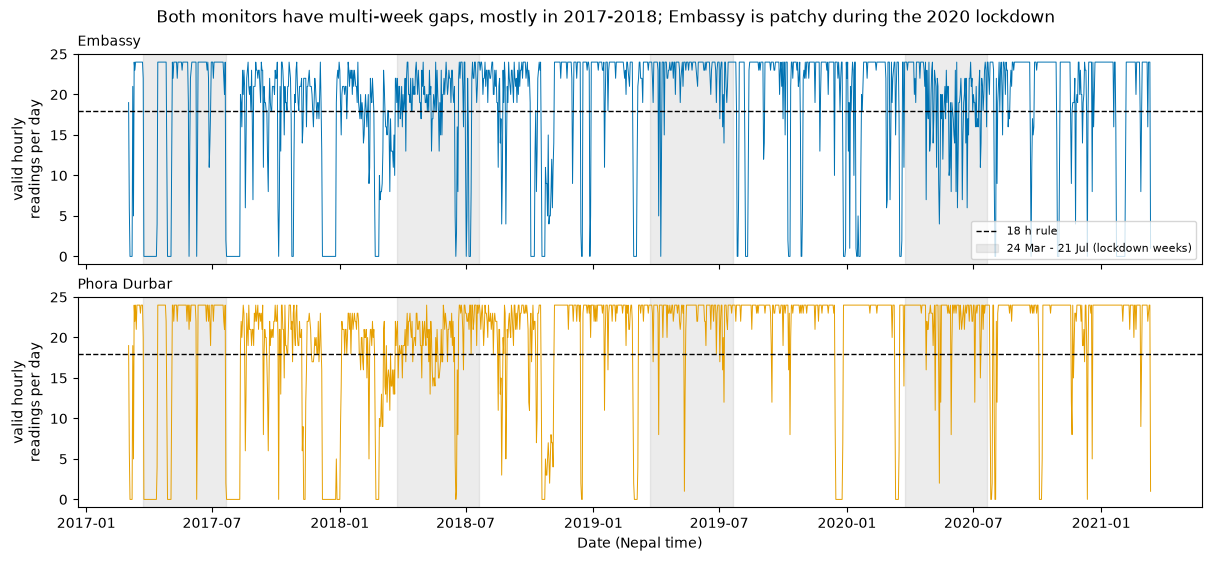

In [42]:
# Plot readings per day, with the lockdown weeks of every year shaded
COLORS = {"Embassy": "#0072B2", "Phora Durbar": "#E69F00"}   # colour-blind-safe (Okabe-Ito)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True, sharey=True, layout="constrained")
for ax, st in zip(axes, daily_n.columns):
    ax.plot(daily_n.index, daily_n[st], lw=0.7, color=COLORS[st])
    ax.axhline(MIN_HOURS, ls="--", lw=1, color="black", label=f"{MIN_HOURS} h rule")
    for y in range(2017, 2021):
        ax.axvspan(pd.Timestamp(f"{y}-03-24"), pd.Timestamp(f"{y}-07-21"), color="grey", alpha=0.15,
                   label="24 Mar - 21 Jul (lockdown weeks)" if y == 2017 else None)
    ax.set_ylabel("valid hourly\nreadings per day")
    ax.set_title(st, loc="left", fontsize=10)
    ax.set_ylim(-1, 25)
axes[0].legend(loc="lower right", fontsize=8)
axes[1].set_xlabel("Date (Nepal time)")
fig.suptitle("Both monitors have multi-week gaps, mostly in 2017-2018; Embassy is patchy during the 2020 lockdown")
plt.show()

In [43]:
# Zoom in on what matters: valid days in the lockdown weeks of each year.
# Window 24 Mar - 21 Jul is PROVISIONAL here; the exact lockdown dates are checked and cited in notebook 02.
rows = []
for y in [2017, 2018, 2019, 2020]:
    w = daily_n.loc[f"{y}-03-24":f"{y}-07-21"]
    for st in w.columns:
        rows.append({"year": y, "station": st, "days in window": len(w),
                     "valid days (>= 18 h)": int((w[st] >= MIN_HOURS).sum()),
                     "empty days": int((w[st] == 0).sum())})
window_cov = pd.DataFrame(rows).set_index(["year", "station"]).unstack("station")
window_cov

days in window              valid days (>= 18 h)               \
station        Embassy Phora Durbar              Embassy Phora Durbar   
year                                                                    
2017               120          120                   85           89   
2018               120          120                   95           93   
2019               120          120                  113          113   
2020               120          120                   84          112   

        empty days               
station    Embassy Phora Durbar  
year                             
2017            27           26  
2018             5            1  
2019             1            0  
2020             0            0

In [44]:
# The longest stretches of days that fail the rule (< 18 h), per station
def longest_gaps(s, min_hours=MIN_HOURS, top=5):
    bad = s < min_hours
    run_id = (bad != bad.shift()).cumsum()          # a new id every time bad/good switches
    runs = s[bad].groupby(run_id[bad]).agg(
        start=lambda x: x.index.min().date(),
        end=lambda x: x.index.max().date(),
        days="size")
    return runs.sort_values("days", ascending=False).head(top).reset_index(drop=True)

for st in daily_n.columns:
    print(st); print(longest_gaps(daily_n[st]), "\n")

Embassy
        start         end  days
0  2017-07-21  2017-08-10    21
1  2017-12-06  2017-12-26    21
2  2017-03-25  2017-04-13    20
3  2018-10-18  2018-11-05    19
4  2021-01-22  2021-02-05    15 

Phora Durbar
        start         end  days
0  2017-12-06  2018-01-03    29
1  2017-07-21  2017-08-10    21
2  2017-03-25  2017-04-13    20
3  2018-10-18  2018-11-05    19
4  2018-02-21  2018-03-04    12 



> **My answer:** **Yes, there are clear gaps, in blocks.** Over **1,472 calendar days**, **Embassy has 148 days and Phora Durbar 121 days with no valid reading at all**. Days passing my rule (**≥ 18 valid hours**): **Embassy 1,118, Phora Durbar 1,202**. The longest gaps are mostly the same at both stations (so probably a shared cause, such as maintenance or a data-feed problem):
- 25 Mar – 13 Apr 2017 (20 days, both)
- 21 Jul – 10 Aug 2017 (21 days, both)
- 6 Dec 2017 – 3 Jan 2018 (Phora Durbar 29 days; Embassy 21 days to 26 Dec)
- 18 Oct – 5 Nov 2018 (19 days, both)

**Inside the lockdown weeks (24 Mar – 21 Jul, 120 days each year), valid days:**

| Year | Embassy | Phora Durbar |
|---|---|---|
| 2017 | 85 (27 empty) | 89 (26 empty) |
| 2018 | 95 (5 empty) | 93 (1 empty) |
| 2019 | 113 (1 empty) | 113 |
| 2020 | **84** | **112** |

**What this means for my question:**
1. **2017 is the weakest baseline year.** It starts in March and misses the first three weeks of the window, so the "2018–2019 only" robustness check matters.
2. **Embassy is patchy in 2020 itself** (only 84 valid days, many days with too few hours in May–June), while **Phora Durbar has 112**. This affects which station to use (see summary).
3. My rule is **≥ 18 of 24 valid hours** (75%), a common completeness rule for daily averages. Days below it are excluded from daily comparisons.

## 8 · Anything else odd?

**Approach:** Notes from earlier exploration you should confirm yourself:
- The data starts in **March 2017**, not 2015 as the publisher's description says. Is the 2017 lockdown-weeks window still covered?
- Is the maximum PM2.5 the same in both files? Suspicious or not?
- Do both stations measure the same things over the same period? Do they agree with each other on days when both have data? (A quick correlation of daily means is enough. This informs your "which station" decision.)

In [45]:
pm.groupby("location")["local_dt"].agg(["min", "max"])

,min,max
location,,
US Diplomatic Post: Embassy Kathmandu,2017-03-03 05:00:00+05:45,2021-03-13 00:00:00+05:45
US Diplomatic Post: Phora Durbar Kathmandu,2017-03-03 05:00:00+05:45,2021-03-13 00:00:00+05:45


In [46]:
# Do the two stations agree? Daily means on days when both have data
daily_mean = valid.groupby(["date", "station"])["value"].mean().unstack("station")
both = daily_mean.dropna()
print(len(both), "days with data at both stations")
print("Correlation of daily means:", round(both.corr().iloc[0, 1], 3))
print("Average daily mean on those days (µg/m³):"); print(both.mean().round(1))

1294 days with data at both stations
Correlation of daily means: 0.918
Average daily mean on those days (µg/m³):
station
Embassy         45.8
Phora Durbar    53.6
dtype: float64


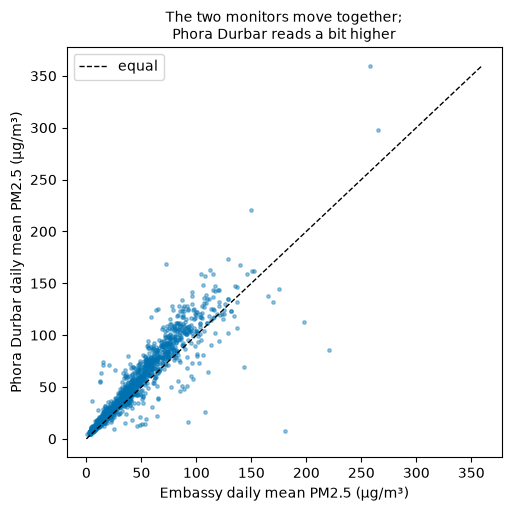

In [47]:
fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")
ax.scatter(both["Embassy"], both["Phora Durbar"], s=6, alpha=0.4, color="#0072B2")
lim = [0, both.max().max()]
ax.plot(lim, lim, color="black", lw=1, ls="--", label="equal")
ax.set_xlabel("Embassy daily mean PM2.5 (µg/m³)")
ax.set_ylabel("Phora Durbar daily mean PM2.5 (µg/m³)")
ax.set_title("The two monitors move together;\nPhora Durbar reads a bit higher", fontsize=10)
ax.legend()
plt.show()

> **My answer:** - **Start date:** both files start on **3 March 2017**, not 2015 as the publisher's description says. The 2017 lockdown-weeks window is covered but partly empty (Q7).
- **Same maximum (985) in both files:** suspicious. It looks like an instrument ceiling (Q3), so those rows will be flagged.
- **The stations agree well:** on **1,294 days** with data at both, their daily means have a **correlation of 0.92**. Phora Durbar (closer to the city centre) reads higher on average: **53.6 vs 45.8 µg/m³**. They tell the same story about *when* air is bad, but the levels differ, so I shouldn't mix them day by day (e.g. using Embassy on some days and Phora Durbar on others).

## 9 · Data quality summary → cleaning rules

Written **before** any lockdown comparison.

| # | Problem found | How many rows (PM2.5) | Rule I will apply | Why |
|---|---|---|---|---|
| 1 | Ozone rows mixed in | 59,545 | Keep `parameter == "pm25"` only | The question is about PM2.5 |
| 2 | Exact duplicates | 0 | Drop (none found, step logged anyway) | No extra information |
| 3 | Placeholder `-999` | 5,784 | Drop the row (hour = missing) | Publisher's code for "no reading" |
| 4 | Other negatives (-1 to -15) | 224 | Drop the row | A concentration can't be negative: sensor error |
| 5 | Isolated spikes (≥ 300 with both neighbours < ⅓ of it) and the 985 ceiling | 64 (53 spikes, 35 at 985, some both) | **Flag `is_suspect`, keep** | Probably glitches, but not certain; test with and without in notebook 02 |
| 6 | Timestamps stored as text | all | Parse `local` → Nepal calendar day | Daily means must use Nepal days (UTC+05:45) |
| 7 | Hours / days missing | 3,922 + 3,468 hours with no row | Daily mean only if **≥ 18 valid hours** | A day with 3 readings isn't a reliable daily average |

**Station decision (recommendation, confirm it's yours):** **Phora Durbar as the main station**, Embassy as a robustness check. Phora Durbar has far more valid days inside the 2020 lockdown weeks (112 vs 84 of 120), and its baseline years are as complete as Embassy's. I don't average the two, because they read at different levels (53.6 vs 45.8 µg/m³) and missing days at one would shift the average.

**Minimum hours for a valid day:** 18 of 24 (75%).

**Rows flagged instead of dropped:** isolated spikes and readings at the 985 ceiling (`is_suspect = True`).

---
# Part B · Cleaning (rules from the summary above, applied in order)

Every step prints rows before → after and goes into a log table for the README. Raw files in `../data/raw/` are never changed. The output goes to `../data/processed/`.

In [48]:
log = []
def log_step(step, why, before, after):
    log.append({"#": len(log) + 1, "step": step, "why": why,
                "rows_before": before, "rows_after": after})
    print(f"{len(log)}. {step}: {before:,} -> {after:,}")

clean = df.copy()

n = len(clean)
clean = clean[clean["parameter"] == "pm25"].copy()
log_step("Keep PM2.5 rows only", "The question is about PM2.5; ozone is a different pollutant", n, len(clean))

n = len(clean)
clean = clean.drop_duplicates()
log_step("Drop exact duplicate rows", "Identical rows add no information (none found)", n, len(clean))

n = len(clean)
clean = clean[clean["value"] != -999]
log_step("Drop -999 rows", "Publisher's placeholder for 'no reading': the hour is missing", n, len(clean))

n = len(clean)
clean = clean[clean["value"] >= 0]
log_step("Drop other negative values (-1 to -15)", "A concentration can't be negative: sensor error", n, len(clean))

1. Keep PM2.5 rows only: 122,755 -> 63,210
2. Drop exact duplicate rows: 63,210 -> 63,210
3. Drop -999 rows: 63,210 -> 57,426
4. Drop other negative values (-1 to -15): 57,426 -> 57,202


In [49]:
# Parse time and add the columns the analysis needs
n = len(clean)
clean["local_dt"] = pd.to_datetime(clean["local"]).dt.tz_localize(None)   # Nepal wall-clock time
clean["date"] = clean["local_dt"].dt.floor("D")                            # Nepal calendar day
clean["station"] = clean["locationId"].map({3459: "embassy", 3460: "phora_durbar"})
log_step("Parse local time; add date and station", "Daily means must use Nepal calendar days (UTC+05:45)", n, len(clean))

5. Parse local time; add date and station: 57,202 -> 57,202


In [50]:
# Flag suspect readings (keep them, but mark them)
# Isolated spike: >= 300 µg/m³ while the hour before AND the hour after are both < 1/3 of it.
# Only count neighbours that are exactly 1 hour away (a gap means we don't know the neighbour).
n = len(clean)
clean = clean.sort_values(["station", "local_dt"]).reset_index(drop=True)
grp = clean.groupby("station")
prev_val, next_val = grp["value"].shift(1), grp["value"].shift(-1)
prev_gap = grp["local_dt"].diff()          # time since the previous row
next_gap = -grp["local_dt"].diff(-1)       # time until the next row
one_hour = pd.Timedelta("1h")

isolated_spike = ((clean["value"] >= 300)
                  & (prev_gap == one_hour) & (prev_val < clean["value"] / 3)
                  & (next_gap == one_hour) & (next_val < clean["value"] / 3))
at_ceiling = clean["value"] >= 985
clean["is_suspect"] = isolated_spike | at_ceiling

print("Isolated spikes:", isolated_spike.sum(), "| at 985 ceiling:", at_ceiling.sum(),
      "| flagged in total:", clean["is_suspect"].sum())
log_step("Flag isolated spikes and 985 ceiling as is_suspect (kept)",
         "Probably glitches, but not certain: test with/without in notebook 02", n, len(clean))

Isolated spikes: 53 | at 985 ceiling: 35 | flagged in total: 64
6. Flag isolated spikes and 985 ceiling as is_suspect (kept): 57,202 -> 57,202


In [51]:
# Daily table: one row per station per Nepal calendar day (including empty days)
MIN_HOURS = 18
daily = (clean.groupby(["station", "date"])
              .agg(n_hours=("value", "size"),
                   pm25_mean=("value", "mean"),
                   pm25_median=("value", "median")))
daily["pm25_mean_no_suspect"] = (clean[~clean["is_suspect"]]
                                 .groupby(["station", "date"])["value"].mean())

full_index = pd.MultiIndex.from_product(
    [sorted(clean["station"].unique()),
     pd.date_range(clean["date"].min(), clean["date"].max(), freq="D")],
    names=["station", "date"])
daily = daily.reindex(full_index)
daily["n_hours"] = daily["n_hours"].fillna(0).astype(int)
daily["valid_day"] = daily["n_hours"] >= MIN_HOURS

print(daily.groupby("station")["valid_day"].agg(["size", "sum"]).rename(columns={"size": "days", "sum": "valid days"}))
daily.head()

              days  valid days
station                       
embassy       1472        1118
phora_durbar  1472        1202


n_hours   pm25_mean  pm25_median  pm25_mean_no_suspect  \
station date                                                                 
embassy 2017-03-03       19  128.615789        95.00            128.615789   
        2017-03-04        6  134.516667       130.35            134.516667   
        2017-03-05        0         NaN          NaN                   NaN   
        2017-03-06        0         NaN          NaN                   NaN   
        2017-03-07        0         NaN          NaN                   NaN   

                    valid_day  
station date                   
embassy 2017-03-03       True  
        2017-03-04      False  
        2017-03-05      False  
        2017-03-06      False  
        2017-03-07      False

In [52]:
# Final checks: these must all pass before saving
assert clean["value"].min() >= 0, "negative values left"
assert not clean.duplicated(subset=["station", "local_dt"]).any(), "duplicate station-hours"
assert clean["local_dt"].dt.minute.eq(0).all(), "readings not on the hour"
print("All checks passed.")

All checks passed.


In [53]:
# Save to data/processed (never to data/raw)
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

hourly_cols = ["station", "locationId", "local_dt", "date", "value", "is_suspect"]
clean[hourly_cols].rename(columns={"value": "pm25"}).to_csv(PROCESSED / "pm25_hourly_clean.csv", index=False)
daily.reset_index().to_csv(PROCESSED / "pm25_daily.csv", index=False)

print("Saved:", PROCESSED / "pm25_hourly_clean.csv", f"({len(clean):,} rows)")
print("Saved:", PROCESSED / "pm25_daily.csv", f"({len(daily):,} rows)")

Saved: ..\data\processed\pm25_hourly_clean.csv (57,202 rows)
Saved: ..\data\processed\pm25_daily.csv (2,944 rows)


### Cleaning log (goes into the README)

In [54]:
cleaning_log = pd.DataFrame(log).set_index("#")
cleaning_log

,step,why,rows_before,rows_after
#,,,,
1,Keep PM2.5 rows only,The question is about PM2.5; ozone is a differ...,122755,63210
2,Drop exact duplicate rows,Identical rows add no information (none found),63210,63210
3,Drop -999 rows,Publisher's placeholder for 'no reading': the ...,63210,57426
4,Drop other negative values (-1 to -15),A concentration can't be negative: sensor error,57426,57202
5,Parse local time; add date and station,Daily means must use Nepal calendar days (UTC+...,57202,57202
6,Flag isolated spikes and 985 ceiling as is_sus...,"Probably glitches, but not certain: test with/...",57202,57202


**Result:** 63,210 PM2.5 rows → **57,202 clean hourly readings** (5,784 `-999` and 224 other negatives removed), of which **64 are flagged `is_suspect`**. The daily table has 1,472 days per station: **1,118 valid days for Embassy and 1,202 for Phora Durbar**.

**What notebook 02 starts from:** `data/processed/pm25_daily.csv`, one row per station per day, with `n_hours`, `pm25_mean`, `pm25_median`, `pm25_mean_no_suspect` and `valid_day`. The main number uses `pm25_mean` on valid days at the chosen station, and the robustness checks swap in the median, the no-suspect mean, the other station, and 2018–2019 only.